<a href="https://colab.research.google.com/github/Chudinow/mood-analiz-Rubert/blob/main/MoodAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 🎯 УМНЫЙ ТРЕКЕР НАСТРОЕНИЯ - ПОЛНАЯ ВЕРСИЯ
# Ячейка 1: Установка и импорт библиотек

print("🚀 ЗАПУСКАЮ ML-МОДУЛЬ ДЛЯ АНАЛИЗА НАСТРОЕНИЯ...")

# Устанавливаем библиотеки
!pip install transformers torch pandas matplotlib seaborn

# Импортируем всё необходимое
from transformers import pipeline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import random
import numpy as np

print("✅ ВСЕ БИБЛИОТЕКИ УСТАНОВЛЕНЫ!")

🚀 ЗАПУСКАЮ ML-МОДУЛЬ ДЛЯ АНАЛИЗА НАСТРОЕНИЯ...
✅ ВСЕ БИБЛИОТЕКИ УСТАНОВЛЕНЫ!


In [ ]:
# Ячейка 2: Создаем анализатор настроения

class MoodAnalyzer:
    def __init__(self):
        print("🧠 Загружаю нейросеть RuBERT для анализа текста...")
        self.classifier = pipeline(
            "sentiment-analysis",
            model="cointegrated/rubert-tiny-sentiment-balanced"
        )
        print("✅ Модель загружена и готова к работе!")

    def analyze_mood(self, text):
        """Анализирует текст и возвращает оценку настроения от 0 до 1"""
        try:
            result = self.classifier(text)[0]

            # Преобразуем в числовую оценку
            if result['label'] == 'positive':
                score = 0.6 + (result['score'] * 0.4)  # 0.6-1.0
            elif result['label'] == 'negative':
                score = result['score'] * 0.4  # 0.0-0.4
            else:  # neutral
                score = 0.4 + (result['score'] * 0.2)  # 0.4-0.6

            return round(score, 2)
        except Exception as e:
            print(f"⚠️ Ошибка при анализе: {e}")
            return 0.5

# Создаем анализатор
print("🎯 Создаю анализатор настроения...")
analyzer = MoodAnalyzer()

🎯 Создаю анализатор настроения...
🧠 Загружаю нейросеть RuBERT для анализа текста...


Device set to use cpu


✅ Модель загружена и готова к работе!


In [ ]:
# Ячейка 3: Тестируем модель на примерах

print("🔍 ТЕСТИРУЮ МОДЕЛЬ НА РАЗНЫХ ТЕКСТАХ:")
print("=" * 50)

test_texts = [
    "Сегодня был просто замечательный день! Все получалось, настроение отличное!",
    "Чувствую себя ужасно, ничего не хочется делать, все валится из рук",
    "Обычный серый день, ничего особенного не произошло, все как всегда",
    "Очень рад успехам в учебе, получил высокие оценки по всем предметам!",
    "Расстроен из-за конфликта с другом, не могу сосредоточиться на учебе"
]

for i, text in enumerate(test_texts, 1):
    mood_score = analyzer.analyze_mood(text)

    # Определяем эмоцию
    if mood_score > 0.8:
        emotion = "😊 РАДОСТЬ"
        color = "🟢"
    elif mood_score > 0.4:
        emotion = "😐 НЕЙТРАЛЬНО"
        color = "🟡"
    else:
        emotion = "😔 ГРУСТЬ"
        color = "🔴"

    print(f"{color} Пример {i}:")
    print(f"   Настроение: {mood_score:.2f} - {emotion}")
    print(f"   Текст: {text}")
    print("-" * 50)

🔍 ТЕСТИРУЮ МОДЕЛЬ НА РАЗНЫХ ТЕКСТАХ:
🟢 Пример 1:
   Настроение: 1.00 - 😊 РАДОСТЬ
   Текст: Сегодня был просто замечательный день! Все получалось, настроение отличное!
--------------------------------------------------
🔴 Пример 2:
   Настроение: 0.39 - 😔 ГРУСТЬ
   Текст: Чувствую себя ужасно, ничего не хочется делать, все валится из рук
--------------------------------------------------
🟡 Пример 3:
   Настроение: 0.80 - 😐 НЕЙТРАЛЬНО
   Текст: Обычный серый день, ничего особенного не произошло, все как всегда
--------------------------------------------------
🟢 Пример 4:
   Настроение: 0.99 - 😊 РАДОСТЬ
   Текст: Очень рад успехам в учебе, получил высокие оценки по всем предметам!
--------------------------------------------------
🔴 Пример 5:
   Настроение: 0.31 - 😔 ГРУСТЬ
   Текст: Расстроен из-за конфликта с другом, не могу сосредоточиться на учебе
--------------------------------------------------


In [ ]:
# Ячейка 4: Создаем демонстрационные данные

print("📊 СОЗДАЮ ДЕМОНСТРАЦИОННЫЕ ДАННЫЕ ЗА 30 ДНЕЙ...")

def create_sample_data(days=30):
    """Создает пример данных для демонстрации"""

    sample_texts = [
        "Сегодня был просто замечательный день! Все получалось, настроение отличное!",
        "Чувствую себя ужасно, ничего не хочется делать, все валится из рук",
        "Обычный серый день, ничего особенного не произошло, все как всегда",
        "Очень рад успехам в учебе, получил высокие оценки по всем предметам!",
        "Расстроен из-за конфликта с другом, не могу сосредоточиться на учебе",
        "Прекрасно провел время с семьей, чувствую себя счастливым и любимым",
        "Устал от постоянной нагрузки, нужен отдых и перезагрузка",
        "Вдохновлен новыми идеями, полон энергии и планов на будущее!",
        "Разочарован результатами, придется пересматривать свои подходы",
        "Спокойный и уравновешенный день, все идет по плану",
        "Отлично поучился, многое понял и разобрался в сложных темах",
        "Потерял мотивацию, сложно заставить себя работать",
        "Нашел новых друзей, было очень интересно общаться",
        "Испытываю стресс из-за дедлайнов, тяжело справляться",
        "Достиг поставленных целей, чувствую удовлетворение"
    ]

    # Создаем данные за указанное количество дней
    data = []
    for i in range(days):
        date = datetime.now() - timedelta(days=days-1-i)
        text = random.choice(sample_texts)
        data.append({
            'date': date.strftime('%Y-%m-%d'),
            'day_name': date.strftime('%A'),
            'text': text
        })

    return pd.DataFrame(data)

# Создаем датафрейм с данными
df = create_sample_data(30)
print(f"✅ Создано {len(df)} записей!")
df.head()

📊 СОЗДАЮ ДЕМОНСТРАЦИОННЫЕ ДАННЫЕ ЗА 30 ДНЕЙ...
✅ Создано 30 записей!


,date,day_name,text
0,2025-10-18,Saturday,"Достиг поставленных целей, чувствую удовлетвор..."
1,2025-10-19,Sunday,"Испытываю стресс из-за дедлайнов, тяжело справ..."
2,2025-10-20,Monday,"Чувствую себя ужасно, ничего не хочется делать..."
3,2025-10-21,Tuesday,"Потерял мотивацию, сложно заставить себя работать"
4,2025-10-22,Wednesday,"Чувствую себя ужасно, ничего не хочется делать..."


In [ ]:
# Ячейка 5: Анализируем все данные

print("🎭 НАЧИНАЮ АНАЛИЗ НАСТРОЕНИЯ ДЛЯ ВСЕХ ЗАПИСЕЙ...")
print("=" * 60)

mood_scores = []
for i, row in df.iterrows():
    mood = analyzer.analyze_mood(row['text'])
    mood_scores.append(mood)

    # Показываем прогресс каждые 5 записей
    if i % 5 == 0:
        emotion = "😊" if mood >= 0.8 else "😐" if mood > 0.4 else "😔"
        print(f"{emotion} {row['date']} - Настроение: {mood:.2f}")
        print(f"   {row['text'][:50]}...")

df['mood_score'] = mood_scores
print(f"\n✅ ПРОАНАЛИЗИРОВАНО {len(df)} ЗАПИСЕЙ!")

🎭 НАЧИНАЮ АНАЛИЗ НАСТРОЕНИЯ ДЛЯ ВСЕХ ЗАПИСЕЙ...
😊 2025-10-18 - Настроение: 0.80
   Достиг поставленных целей, чувствую удовлетворение...
😐 2025-10-23 - Настроение: 0.50
   Разочарован результатами, придется пересматривать ...
😔 2025-10-28 - Настроение: 0.33
   Устал от постоянной нагрузки, нужен отдых и переза...
😔 2025-11-02 - Настроение: 0.39
   Чувствую себя ужасно, ничего не хочется делать, вс...
😔 2025-11-07 - Настроение: 0.33
   Устал от постоянной нагрузки, нужен отдых и переза...
😊 2025-11-12 - Настроение: 1.00
   Прекрасно провел время с семьей, чувствую себя сча...

✅ ПРОАНАЛИЗИРОВАНО 30 ЗАПИСЕЙ!


📈 СОЗДАЮ ИНТЕРАКТИВНЫЕ ГРАФИКИ АНАЛИЗА...


/tmp/ipython-input-2714047502.py:81: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2714047502.py:81: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2714047502.py:81: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2714047502.py:81: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabt

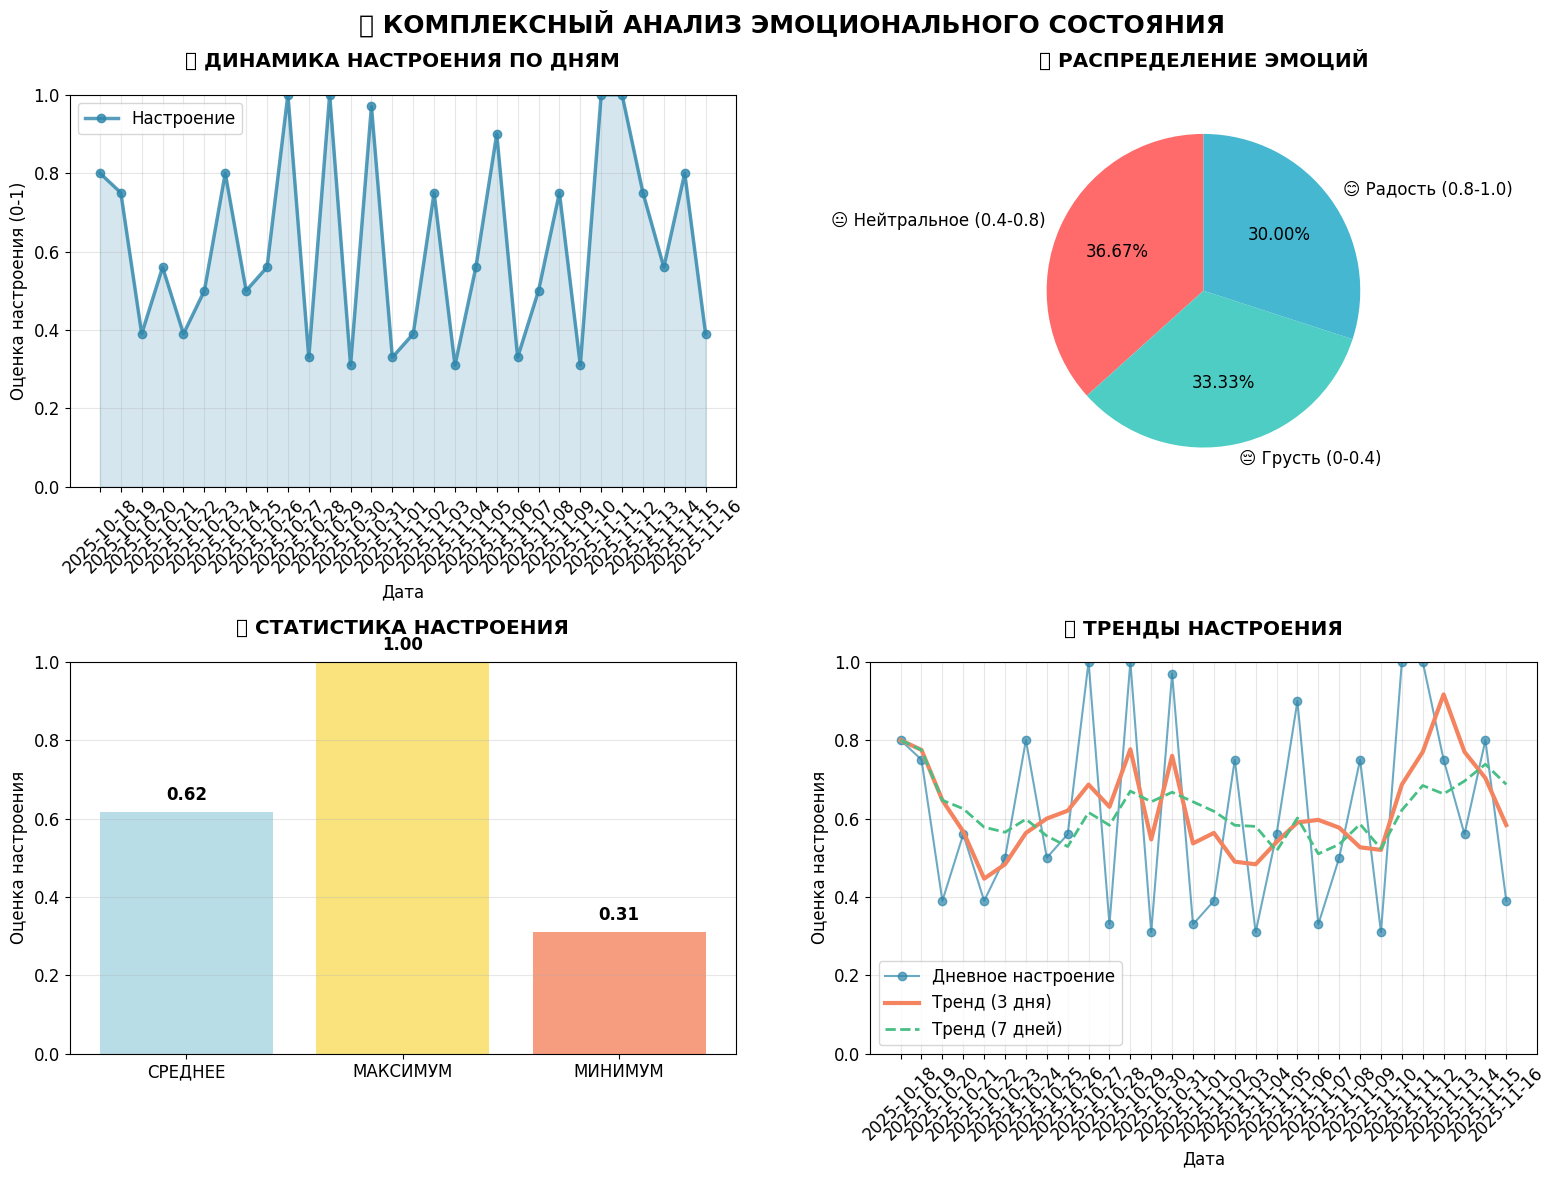

In [ ]:
# Ячейка 6: Создаем красивые визуализации

print("📈 СОЗДАЮ ИНТЕРАКТИВНЫЕ ГРАФИКИ АНАЛИЗА...")

# Настраиваем стиль графиков
plt.style.use('default')
plt.rcParams['figure.figsize'] = (15, 12)
plt.rcParams['font.size'] = 12

# Создаем 4 графика
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('📊 КОМПЛЕКСНЫЙ АНАЛИЗ ЭМОЦИОНАЛЬНОГО СОСТОЯНИЯ',
             fontsize=18, fontweight='bold', y=0.98)

# График 1: Динамика настроения по дням
axes[0, 0].plot(df['date'], df['mood_score'], marker='o', linewidth=2.5,
                markersize=6, color='#2E86AB', label='Настроение', alpha=0.8)
axes[0, 0].fill_between(df['date'], df['mood_score'], alpha=0.2, color='#2E86AB')
axes[0, 0].set_title('📅 ДИНАМИКА НАСТРОЕНИЯ ПО ДНЯМ', fontweight='bold', pad=20)
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Оценка настроения (0-1)')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim(0, 1)
axes[0, 0].legend()

# График 2: Распределение эмоций
mood_categories = []
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
labels = ['😔 Грусть (0-0.4)', '😐 Нейтральное (0.4-0.8)', '😊 Радость (0.8-1.0)']

for score in df['mood_score']:
    if score >= 0.8:
        mood_categories.append(labels[2])
    elif score >= 0.4:
        mood_categories.append(labels[1])
    else:
        mood_categories.append(labels[0])

mood_counts = pd.Series(mood_categories).value_counts()
wedges, texts, autotexts = axes[0, 1].pie(mood_counts.values, labels=mood_counts.index,
                                         autopct='%1.2f%%', colors=colors, startangle=90)
axes[0, 1].set_title('🎭 РАСПРЕДЕЛЕНИЕ ЭМОЦИЙ', fontweight='bold', pad=20)

# График 3: Статистика
stats_names = ['СРЕДНЕЕ', 'МАКСИМУМ', 'МИНИМУМ']
stats_values = [df['mood_score'].mean(), df['mood_score'].max(), df['mood_score'].min()]
colors_stats = ['#A8D5E2', '#F9DC5C', '#F4845F']

bars = axes[1, 0].bar(stats_names, stats_values, color=colors_stats, alpha=0.8)
axes[1, 0].set_title('📊 СТАТИСТИКА НАСТРОЕНИЯ', fontweight='bold', pad=20)
axes[1, 0].set_ylabel('Оценка настроения')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bar, value in zip(bars, stats_values):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                   f'{value:.2f}', ha='center', va='bottom', fontweight='bold')

# График 4: Тренд и скользящее среднее
df_sorted = df.sort_values('date').reset_index(drop=True)
df_sorted['trend_3d'] = df_sorted['mood_score'].rolling(window=3, min_periods=1).mean()
df_sorted['trend_7d'] = df_sorted['mood_score'].rolling(window=7, min_periods=1).mean()

axes[1, 1].plot(df_sorted['date'], df_sorted['mood_score'], 'o-', alpha=0.7,
                label='Дневное настроение', color='#2E86AB')
axes[1, 1].plot(df_sorted['date'], df_sorted['trend_3d'], '-', linewidth=3,
                label='Тренд (3 дня)', color='#F4845F')
axes[1, 1].plot(df_sorted['date'], df_sorted['trend_7d'], '--', linewidth=2,
                label='Тренд (7 дней)', color='#48BF84')
axes[1, 1].set_title('📈 ТРЕНДЫ НАСТРОЕНИЯ', fontweight='bold', pad=20)
axes[1, 1].set_xlabel('Дата')
axes[1, 1].set_ylabel('Оценка настроения')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
# Ячейка 7: Детальная аналитика и выводы

print("📋 ДЕТАЛЬНЫЙ АНАЛИТИЧЕСКИЙ ОТЧЕТ")
print("=" * 60)

# Базовая статистика
avg_mood = df['mood_score'].mean()
max_mood = df['mood_score'].max()
min_mood = df['mood_score'].min()
best_day = df.loc[df['mood_score'].idxmax()]
worst_day = df.loc[df['mood_score'].idxmin()]

print(f"📅 Период анализа: {len(df)} дней")
print(f"📊 Среднее настроение: {avg_mood:.2f}")
print(f"🎯 Лучший день: {best_day['date']} - {max_mood:.2f}")
print(f"   Текст: {best_day['text']}")
print(f"⚠️  Сложный день: {worst_day['date']} - {min_mood:.2f}")
print(f"   Текст: {worst_day['text']}")

# Анализ тренда
first_week_avg = df_sorted['mood_score'].head(7).mean()
last_week_avg = df_sorted['mood_score'].tail(7).mean()
trend_change = last_week_avg - first_week_avg

print(f"\n📈 АНАЛИЗ ТРЕНДА:")
print(f"   Первая неделя: {first_week_avg:.2f}")
print(f"   Последняя неделя: {last_week_avg:.2f}")

if trend_change > 0.1:
    trend_emoji = "🚀📈"
    trend_text = "ЗНАЧИТЕЛЬНОЕ УЛУЧШЕНИЕ"
elif trend_change > 0.05:
    trend_emoji = "📈"
    trend_text = "УЛУЧШЕНИЕ"
elif trend_change > -0.05:
    trend_emoji = "➡️"
    trend_text = "СТАБИЛЬНО"
elif trend_change > -0.1:
    trend_emoji = "📉"
    trend_text = "СНИЖЕНИЕ"
else:
    trend_emoji = "⚠️📉"
    trend_text = "ЗНАЧИТЕЛЬНОЕ СНИЖЕНИЕ"

print(f"   Изменение: {trend_change:+.2f} - {trend_emoji} {trend_text}")

# Распределение по категориям
positive_days = len([x for x in df['mood_score'] if x >= 0.8])
neutral_days = len([x for x in df['mood_score'] if 0.4 <= x < 0.8])
negative_days = len([x for x in df['mood_score'] if x < 0.4])

print(f"\n🎭 РАСПРЕДЕЛЕНИЕ ДНЕЙ:")
print(f"   😊 Радостных дней: {positive_days} ({positive_days/len(df)*100:.1f}%)")
print(f"   😐 Нейтральных дней: {neutral_days} ({neutral_days/len(df)*100:.1f}%)")
print(f"   😔 Грустных дней: {negative_days} ({negative_days/len(df)*100:.1f}%)")

print("=" * 60)

📋 ДЕТАЛЬНЫЙ АНАЛИТИЧЕСКИЙ ОТЧЕТ
📅 Период анализа: 30 дней
📊 Среднее настроение: 0.62
🎯 Лучший день: 2025-10-27 - 1.00
   Текст: Сегодня был просто замечательный день! Все получалось, настроение отличное!
⚠️  Сложный день: 2025-10-30 - 0.31
   Текст: Расстроен из-за конфликта с другом, не могу сосредоточиться на учебе

📈 АНАЛИЗ ТРЕНДА:
   Первая неделя: 0.60
   Последняя неделя: 0.69
   Изменение: +0.09 - 📈 УЛУЧШЕНИЕ

🎭 РАСПРЕДЕЛЕНИЕ ДНЕЙ:
   😊 Радостных дней: 9 (30.0%)
   😐 Нейтральных дней: 11 (36.7%)
   😔 Грустных дней: 10 (33.3%)


In [ ]:
# Ячейка 8: Сохраняем результаты

print("💾 СОХРАНЯЮ РЕЗУЛЬТАТЫ...")

# Сохраняем в CSV
df.to_csv('mood_analysis_results.csv', index=False, encoding='utf-8')

# Создаем краткий отчет
report = f"""
🎯 ОТЧЕТ АНАЛИЗА НАСТРОЕНИЯ
📅 Период: {len(df)} дней
📊 Среднее настроение: {avg_mood:.2f}
🎭 Распределение: {positive_days}😊 {neutral_days}😐 {negative_days}😔
📈 Тренд: {trend_text} ({trend_change:+.2f})
"""

print(report)
print("✅ Результаты сохранены в 'mood_analysis_results.csv'")
print("🎉 ML-МОДУЛЬ УСПЕШНО СОЗДАН И ПРОТЕСТИРОВАН!")

💾 СОХРАНЯЮ РЕЗУЛЬТАТЫ...

🎯 ОТЧЕТ АНАЛИЗА НАСТРОЕНИЯ
📅 Период: 30 дней
📊 Среднее настроение: 0.62
🎭 Распределение: 9😊 11😐 10😔
📈 Тренд: УЛУЧШЕНИЕ (+0.09)

✅ Результаты сохранены в 'mood_analysis_results.csv'
🎉 ML-МОДУЛЬ УСПЕШНО СОЗДАН И ПРОТЕСТИРОВАН!
